In [1]:
import numpy as np
import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
# from sklearn.datasets import make_blobs
import seaborn as sns

In [2]:
 # make 3-class dataset for classification
def generate_three_concentric_classes(n_samples_per_class=500,noise=0.05):

  np.random.seed(0)
  X = []
  y = []
  radii = [0.3, 0.6, 0.9]
  for label, r in enumerate(radii):
    theta = 2 * np.pi * np.random.rand(n_samples_per_class)
    x = r * np.cos(theta) + noise * np.random.randn(n_samples_per_class)
    y_ = r * np.sin(theta) + noise *np.random.randn(n_samples_per_class)
    X.append(np.stack([x, y_], axis=1))
    y.append(np.full(n_samples_per_class, label))
  return np.vstack(X), np.concatenate(y)
 # Example usage
x, y = generate_three_concentric_classes()


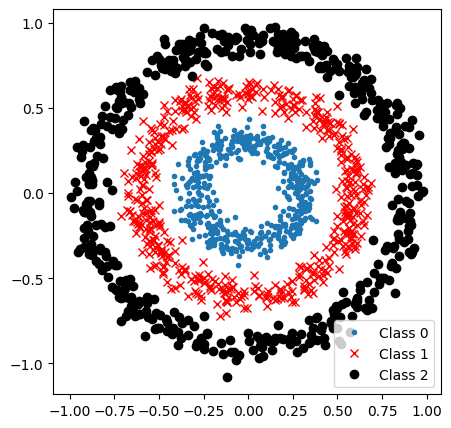

In [3]:
 idx0 = np.argwhere(y == 0)
 idx1 = np.argwhere(y == 1)
 idx2 = np.argwhere(y == 2)
 fig = plt.figure(figsize=(5,5))
 plt.plot(x[idx0,0], x[idx0,1], '.', label="Class 0")
 plt.plot(x[idx1,0], x[idx1,1], "rx", label="Class 1")
 plt.plot(x[idx2,0], x[idx2,1], "ko", label="Class 2")
 plt.xlabel("")
 plt.ylabel("")
 plt.legend()
 plt.show()

In [4]:
def to_one_hot(y):
    n_classes = y.max() + 1
    m = len(y)
    Y_one_hot = np.zeros((m, n_classes))
    Y_one_hot[np.arange(m), y] = 1
    return Y_one_hot

def softmax(logits):
    exps = np.exp(logits)
    exp_sums = np.sum(exps, axis=1, keepdims=True)
    return exps / exp_sums

def error_function(x, a, y, epsilon=1e-7):
    logits = x.dot(a)
    y_prob = softmax(logits)
    error = -np.mean(np.sum(y * np.log(y_prob + epsilon), axis=1))
    return error

def classifier(x, a):
    logits = x.dot(a)
    y_prob = softmax(logits)
    c = np.zeros((len(y_prob), 1))
    for i in range(0, len(y_prob)):
        c[i, 0] = np.argmax(y_prob[i, :])
    return c

def predict_prob(x, a):
    logits = x.dot(a)
    y_prob = softmax(logits)
    return y_prob

def compute_confusion_matrix(y_true, y_pred, num_classes):

    y_true_labels = np.argmax(y_true, axis=1)
    conf_matrix = np.zeros((num_classes, num_classes), dtype=int)
    for true_label, pred_label in zip(y_true_labels, y_pred.flatten()):
        conf_matrix[true_label, int(pred_label)] += 1

    return conf_matrix

In [5]:
n_samples = x.shape[0]
indices = np.arange(n_samples)
np.random.shuffle(indices)

train_size = int(0.75 * n_samples)

train_idx = indices[:train_size]
val_idx = indices[train_size:]

x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

y_train = to_one_hot(y_train.flatten().astype(int))
y_val = to_one_hot(y_val.flatten().astype(int))

In [6]:
# Batch gradient descent solution.

# learning rate.
alpha = 0.1
# Maximum number of iterations.
n_iterations = 50000

# Random initialization of parameters.
a = np.random.randn(x_train.shape[1], 3) * 0.01


# Create array for storing error values.
Jgd = np.zeros(n_iterations+1)
Jgd_v = np.zeros(n_iterations+1)

# Calculate initial error.
Jgd[0] = error_function(x_train, a, y_train)
Jgd_v[0] = error_function(x_val, a, y_val)

# Batch gradient-descent loop.
minimum_val_error = float("inf")
iteration = 0
error = 1
while iteration < n_iterations:
    gradients = -1/len(y_train)*x_train.T.dot(y_train - softmax(x_train.dot(a)) )
    a = a - alpha * gradients
    Jgd[iteration+1] = error_function(x_train, a, y_train)
    Jgd_v[iteration+1] = error_function(x_val, a, y_val)
    error = np.abs(Jgd[iteration+1] - Jgd[iteration])
    # Store weights for the smallest error ever.
    if(Jgd_v[iteration+1] < minimum_val_error):
        minimum_val_error = Jgd_v[iteration+1]
        a_min = a
    iteration = iteration + 1



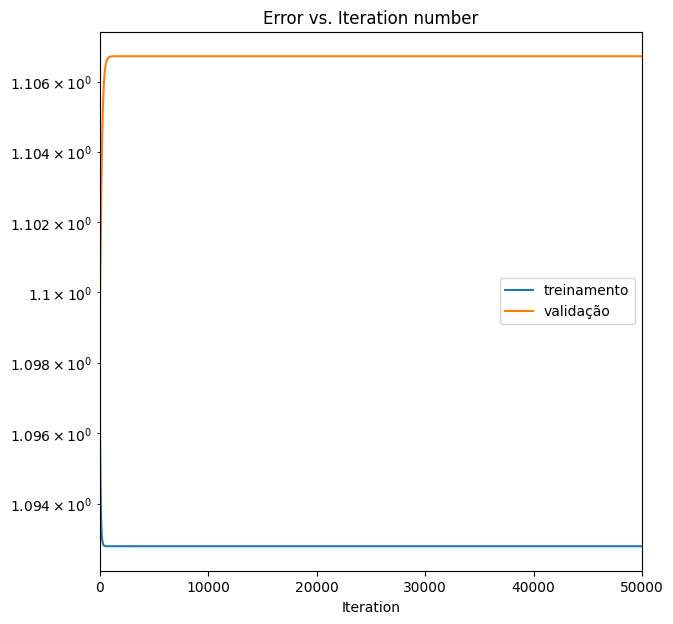

In [7]:

fig = plt.figure(figsize=(7,7))
plt.plot(np.arange(0, iteration), Jgd[0:iteration], label='treinamento')
plt.plot(np.arange(0, iteration), Jgd_v[0:iteration], label='validação')
plt.xlim((0, iteration))
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('')
plt.title('Error vs. Iteration number')
plt.legend()
plt.show()


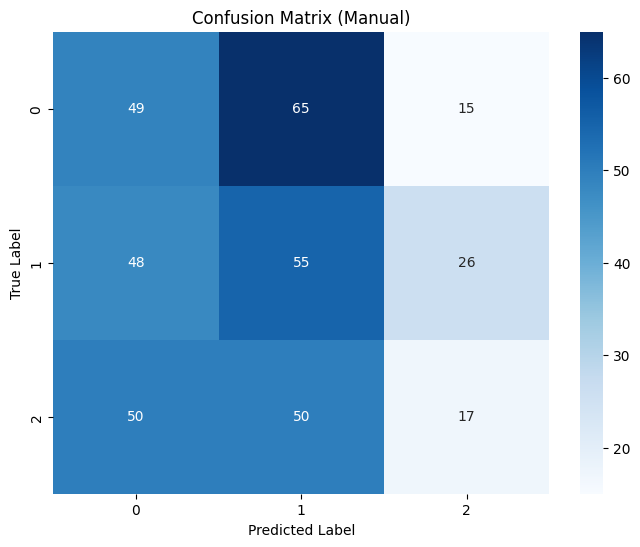

In [8]:

y_pred_val = classifier(x_val, a_min)


num_classes = y_val.shape[1]
conf_matrix = compute_confusion_matrix(y_val, y_pred_val, num_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Manual)')
plt.show()

/tmp/ipython-input-9-7610342.py:17: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],


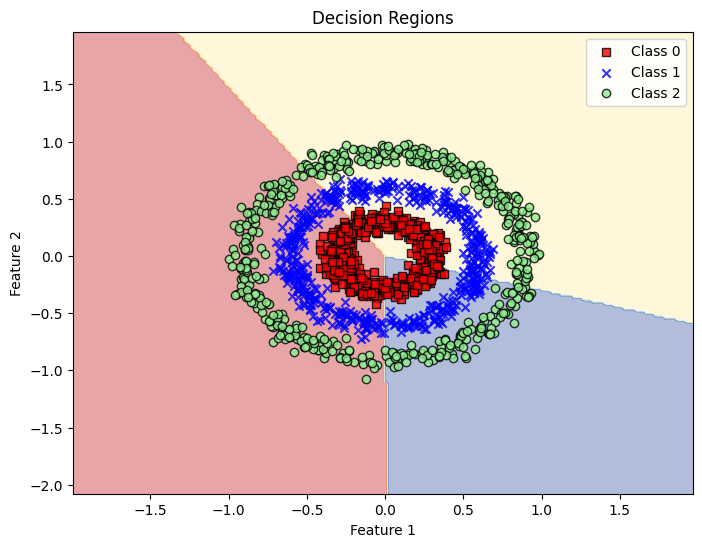

In [9]:

def plot_decision_regions(X, y, classifier, resolution=0.02):
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = plt.cm.RdYlBu
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier(np.c_[xx1.ravel(), xx2.ravel()], a_min)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    # plot class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=colors[idx],
                    marker=markers[idx], label=f'Class {cl}',
                    edgecolor='black')

plt.figure(figsize=(8, 6))
plot_decision_regions(x, y.flatten(), classifier)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Regions')
plt.legend()
plt.show()

In [11]:
from sklearn.metrics import classification_report
y_true_labels_val = np.argmax(y_val, axis=1)

print(classification_report(y_true_labels_val, y_pred_val))



#Não lembto como faz sem usar o sklearn :(

              precision    recall  f1-score   support

           0       0.33      0.38      0.36       129
           1       0.32      0.43      0.37       129
           2       0.29      0.15      0.19       117

    accuracy                           0.32       375
   macro avg       0.32      0.32      0.31       375
weighted avg       0.32      0.32      0.31       375

